### This explains the geoprocessing flow used to interpolate IDFs and perform SCMC analysis

All analysis were performed using Esri ArcGIS Pro 3.5.0

Requires Spatial Analyst and Image Analyst Extensions to run exactly as described below.

### Apply the following geoprocessing workflows for interpolation:

csv -> point feature -> ordinary kriging (produced 54 raster maps)

Tools used:
1. XY Table To Point
2. Kriging (OrdinaryKriging)

Kriging tool paramter settings used for all

*kriging method == Ordinary
semivariogramType == EXPONENTIAL
lag == 0.42
out cell_size == 0.0555
search radius == Variable*

### For GCM IDF csv's

Kriging tool paramter settings used for GCMs

*Z value field == mean
                  95th
                  5th*
*numberofPoints == 12*

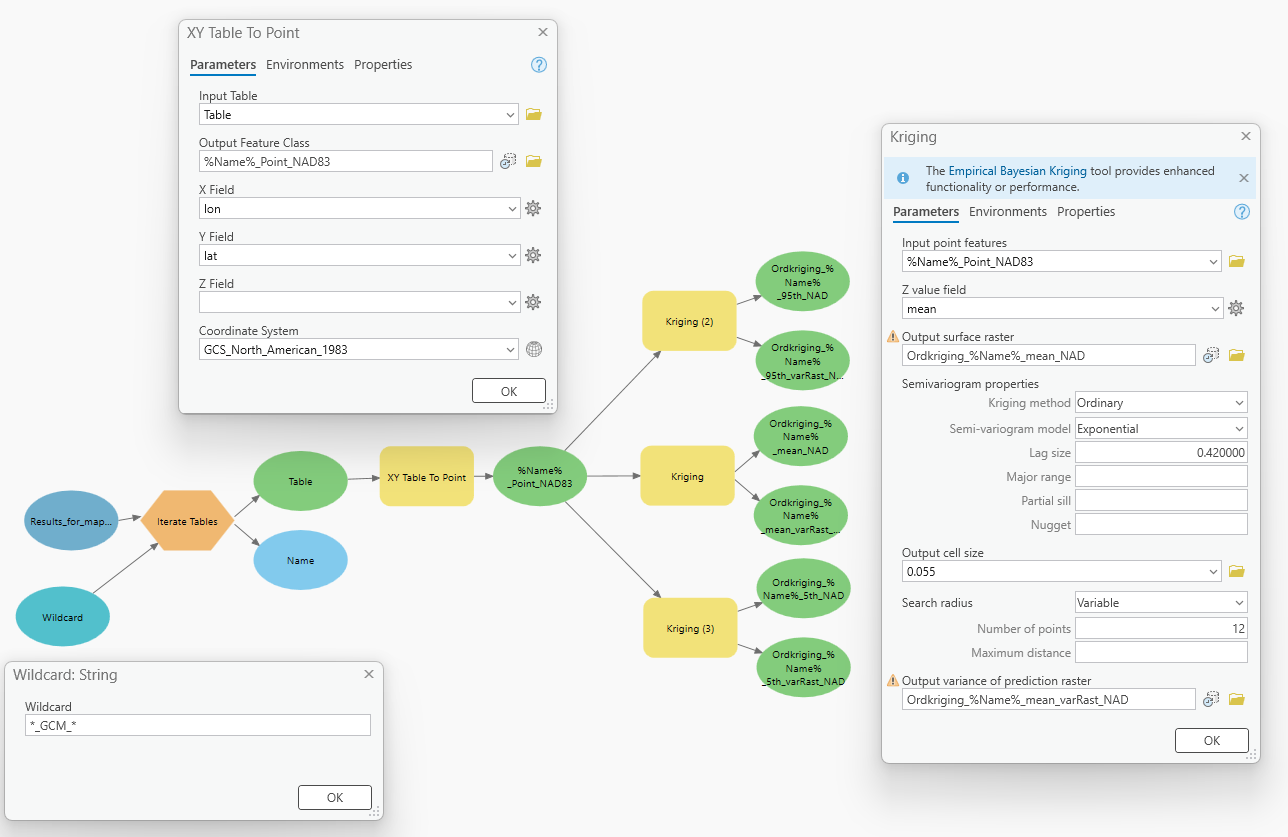

### For CF and CF CVs csv's
Kriging tool paramter settings used for CFs and CVs

*Z value field == mean
                  95th
                  5th
                  CV*
                  
*numberofPoints == 12*

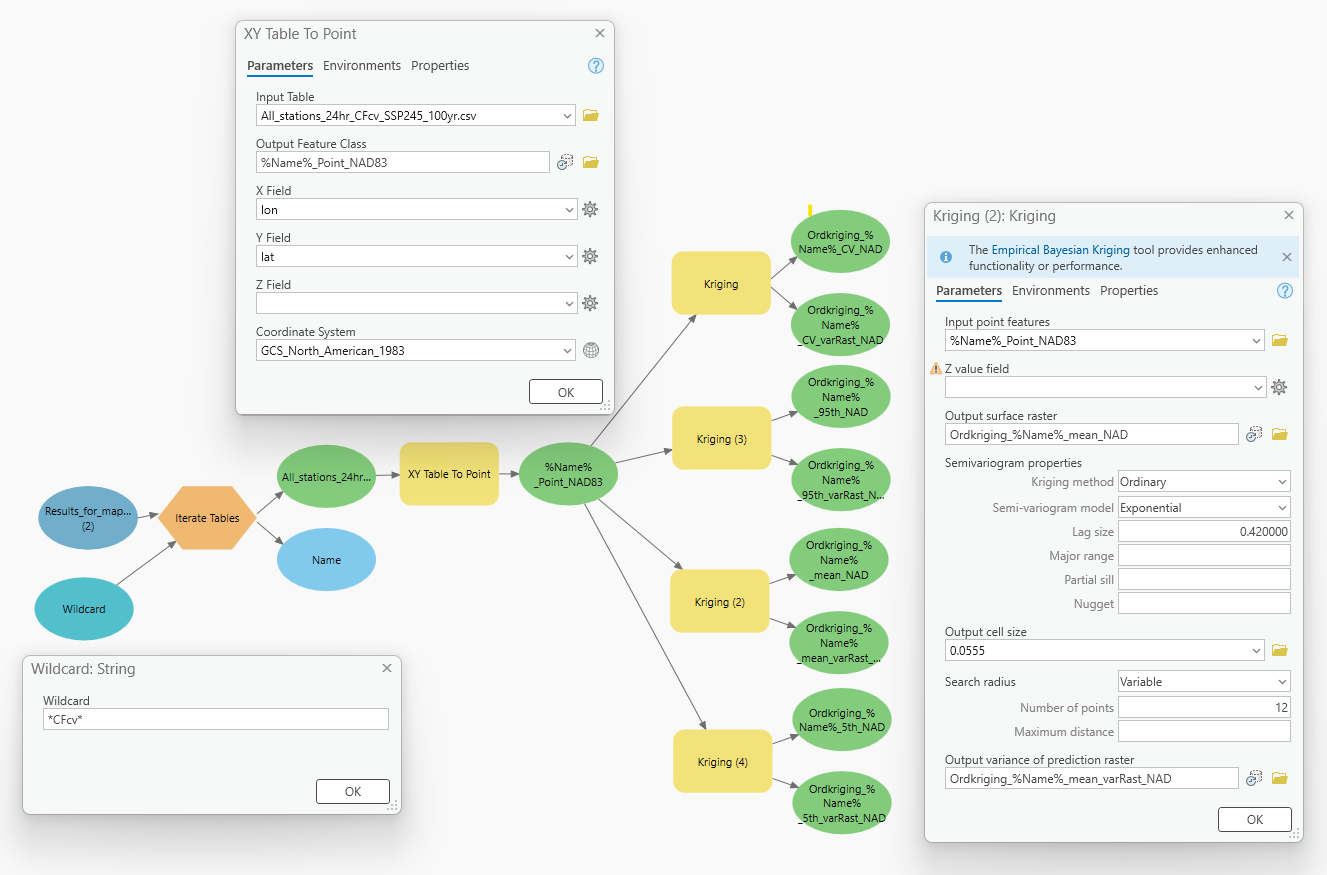

### For the Observation csv's
Kriging tool paramter settings used for GCMs

*Z value field == mean*
                  
*numberofPoints == 10*

*maxDistance == 3.2*

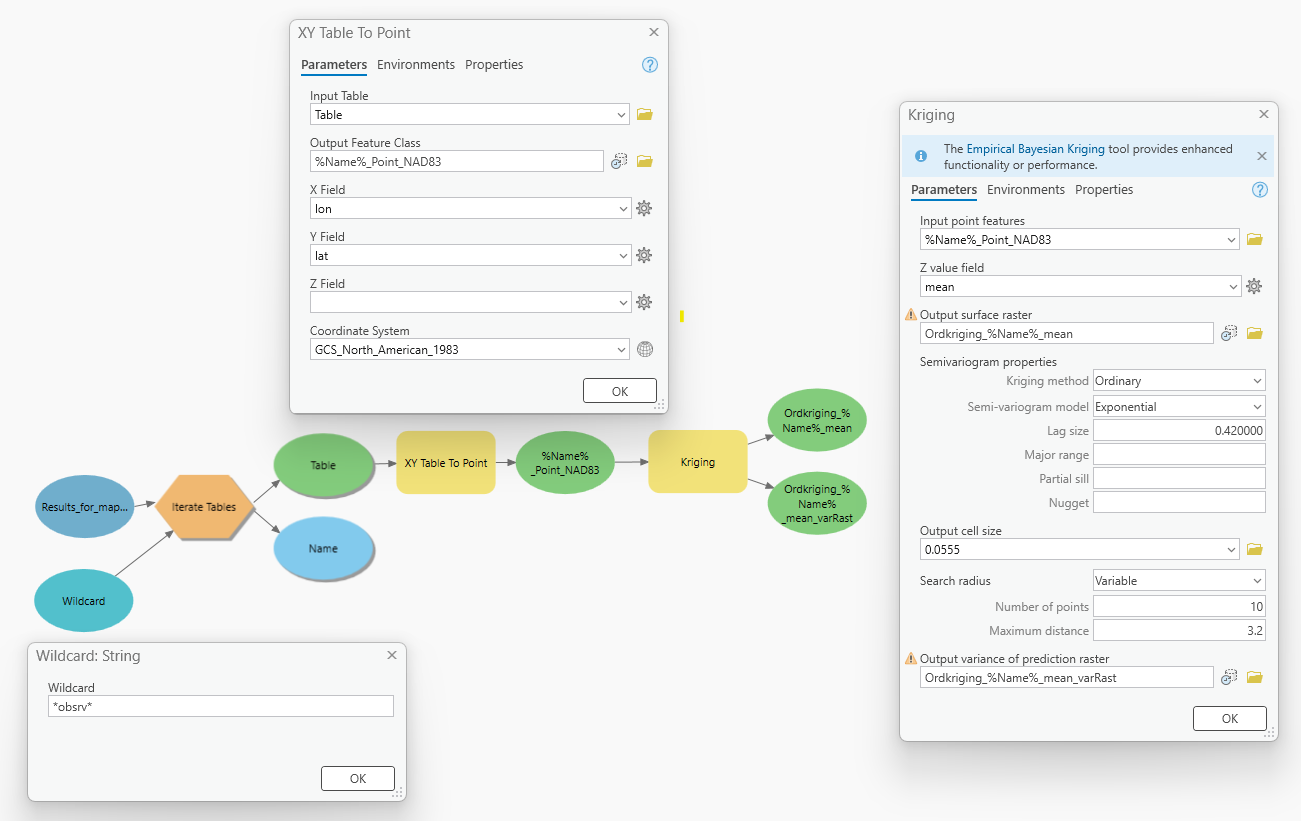


### Apply the following geoprocessing workflows for CF-CV spatially contstrained multi-variate cluster analysis:
raster -> point feature -> sampled point feature -> SCMC analysis -> SCMC point feautre -> SCMC raster -> SCMC polygon -> union (1 polygon layer)

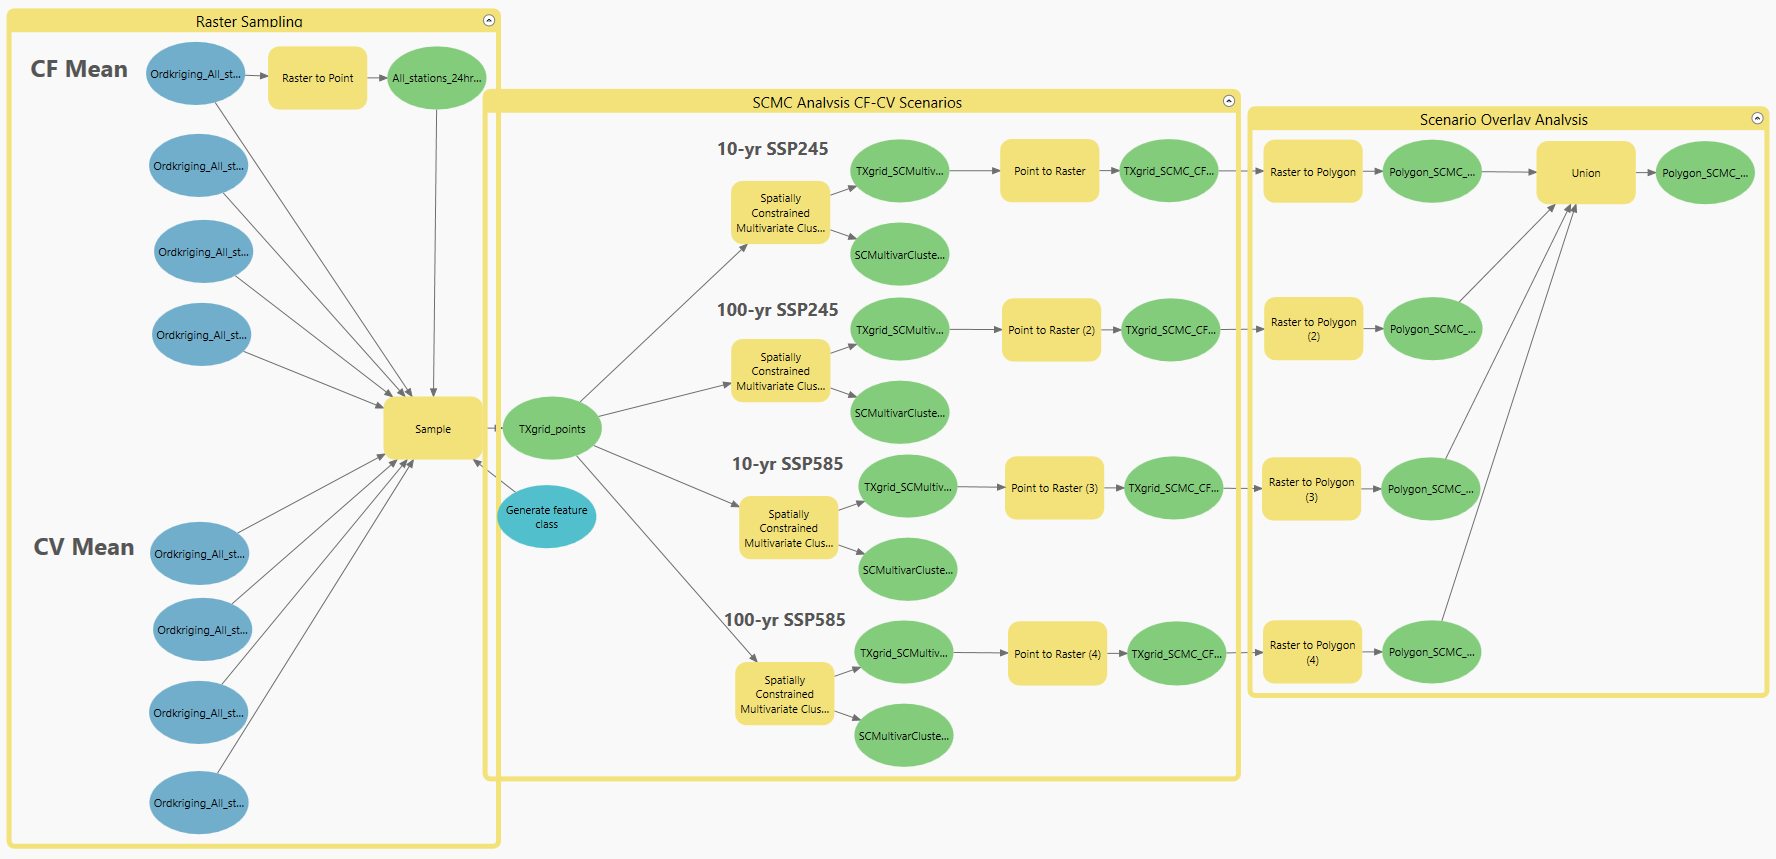

**Raster Sampling**

Sample the mean CF and CV rasters from kriging results

Tools used:

3. Raster to Point
4. Sample

Convert one input raster into point feature to use as in location feature layer

Sample tool input parameter settings

*Input rasters ==*

    CF Mean 10-yr SSP245
    CF Mean 100-yr SSP245
    CF Mean 10-yr SSP585
    CF Mean 100-yr SSP585
    CV Mean 10-yr SSP245
    CV Mean 100-yr SSP245
    CV Mean 10-yr SSP585
    CV Mean 100-yr SSP585
    
*resampling type == NEAREST*

*unique id field == OBJECTID*

**SCMC Analysis**

Using the gridded point feautre layer that sampled all rasters perform 4 SCMC analyses on CF-CV combinations for IDF and GCM scenarios

Tools used:

5. Spatially Constrained Multivariate Clustering
6. Point to Raster

Spatially Constrained Multivariate Clustering tool parameter settings

*Analysis Fields ==*

    10-yr SSP245 CF / 10-yr SSP245 CV;
    100-yr SSP245 CF / 100-yr SSP245 CV;
    10-yr SSP585 CF / 10-yr SSP585 CV;
    100-yr SSP585 CF / 100-yr SSP585 CV
    
These combinations in a row must be run one at a time

*Cluster size constraint == None*

*number of clusters == None*

*spatial constraints == TRIMMED_DELAUNAY_TRIANGULATION*

*number of permutations == 100*

Convert each output point feature to raster using Point To Raster

input parameter settings

*value field == CLUSTER_ID*

*cell assignment == MOST_FREQUENT*

*priority field == NONE*

*cellsize == 10-yr SSP245 CF OR 0.0555*

*build raster attribute table == BUILD*

**Overlay Analysis**

Convert the 4 rasters to polygons and perform union overlay analysis

Tools used:

7. Raster to Polygon
8. Union

Raster to polygon tool parameter settings

*simplify == SIMPLIFY*

*raster field == VALUE*

*create multipart features == SINGLE_OUTER_PART*

Union tool paramter settings
*input features ==* 

    10-yr SSP245 CF-CV SCMC polygon
    100-yr SSP245 CF-CV SCMC polygon
    10-yr SSP585 CF-CV SCMC polygon
    100-yr SSP585 CF-CV SCMC polygon
    
*join_attributes == ALL*

*gaps == NO_GAPS*